In [15]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [16]:
df = pd.read_csv('GGXY.csv')
df = df[['Club','Ball Speed (MPH)','Launch Angle (Deg)','Face Angle (Deg)','Face to Path (Deg)', 'Carry (Yds)']] #only keep key metrics

#remove rows without data
df.replace('-',np.nan,inplace=True)
df.dropna(inplace=True)

display(df)

,Club,Ball Speed (MPH),Launch Angle (Deg),Face Angle (Deg),Face to Path (Deg),Carry (Yds)
0,54 Wedge,96.4,27.7,-5.7,-7.5,119.1
2,54 Wedge,94.6,29.6,-4.5,-6.7,116.1
3,54 Wedge,94.3,30.6,-5.1,-8.3,121.6
5,54 Wedge,92.8,30.3,0.9,-0.9,110.9
6,54 Wedge,96.8,26.6,-5,-6.4,120.7
...,...,...,...,...,...,...
181,7 Iron,77.8,7.8,-12.3,-9.9,44.4
183,7 Iron,70.8,18.8,-3,2.4,73.9
185,7 Iron,81.3,15.0,4.1,8.7,91.3
187,7 Iron,88.2,16.0,-2.2,-2.2,108.5


In [37]:
data = np.array(df)
num_rows, num_cols = data.shape

#make sure all numbers are floats instead of strings
for i in range(num_rows):
    data[i,0] = int(i)
    for j in range(num_cols):
        data[i,j] = float(data[i,j])

In [18]:
def distance(ball_speed,launch_angle,g=9.8):
    angle = math.radians(launch_angle)
    speed = ball_speed * 0.488889 #correct to yards per second
    range = (speed**2) * math.sin(2*angle) / g
    return range

In [61]:
def direction(face_angle,face_to_path):
    #weighted contributions to the ball's direction
    face_angle_weight = 1 
    face_path_weight = 1 
    curve_constant = 1 #changes with external conditions

    #the final direction is a combination of both
    start_direction = face_angle_weight * face_angle + face_path_weight * face_to_path
    curve = curve_constant * (face_angle-face_to_path)

    #final direction
    direction = start_direction + curve
    
    return direction #this is in degrees

In [62]:
def final(distance, degrees):
    carry = distance / math.cos(math.radians(degrees)) #using trig
    return carry #yards

## Here's an example of a driver shot by Tiger Woods

In [63]:
ex_faceangle = 0
ex_face2path = 2 #assume a little fade
ex_ballspeed = 180 #mph
ex_launchangle = 12 #degrees

ex_distance = distance(ex_ballspeed,ex_launchangle)
ex_direction = direction(ex_faceangle,ex_face2path)

ex_final = final(ex_distance,ex_direction)
print(f'Predicted carry: {ex_final:.2f} yards, {ex_direction} degrees away from center')

Predicted carry: 321.41 yards, 0 degrees away from center


(-5.0, 350.0)

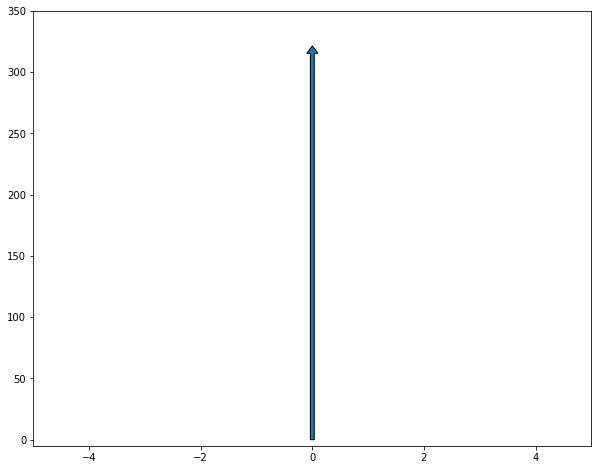

In [64]:
direction_yards = math.sqrt(ex_final**2 - ex_distance**2)

plt.figure(figsize=(10,8))
plt.arrow(0,0, direction_yards, ex_distance, width = 0.07, head_width=0.2, head_length = 6, length_includes_head = True)
plt.xlim(-5,5)
plt.ylim(-5,350)

### Prediction on all the data

In [65]:
def predict(data,index):
    #extract relevant data from the i-th shot
    ball_speed, launch_angle, face_angle, face_to_path = data[index,1:5]
    true_carry = data[index,5]
    
    #call previously written functions
    dist = distance(ball_speed,launch_angle)
    degrees = direction(face_angle,face_to_path)

    carry = final(dist,degrees)
    direction_yards = math.sqrt(carry**2 - dist**2)
    
    print(f'Predicted carry: {carry:.2f} yards, {degrees:.2f} degrees ({direction_yards:.2f} yards) away from center')
    
    #deviation can be positive or negative
    deviation = carry-true_carry
    print(f'Carry deviation: {deviation:.2f} yards \n')
    
    return deviation

### PCA

Feature 1: 0.8802671131542231
Feature 2: 0.06393468972629311
Feature 3: 0.04378548230731741
Feature 4: 0.012012714812166292


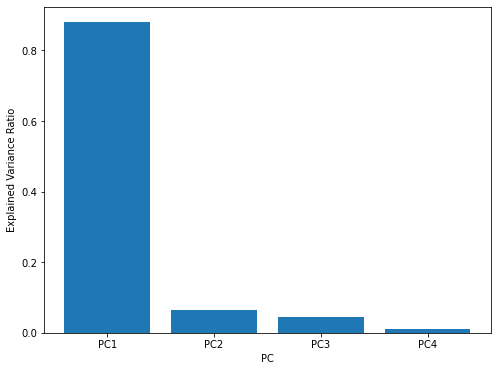

In [66]:
from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler

#X are features
X = df[['Ball Speed (MPH)', 'Launch Angle (Deg)', 'Face Angle (Deg)', 'Face to Path (Deg)']]

#standard PCA procedure
pca = PCA()
pca.fit(X)
explained_variance = pca.explained_variance_ratio_

for i in range(len(explained_variance)):
    print(f'Feature {i+1}:', explained_variance[i])

plt.figure(figsize=(8, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, 
        tick_label=[f'PC{i}' for i in range(1, len(explained_variance) + 1)])
plt.xlabel("PC")
plt.ylabel("Explained Variance Ratio")
plt.show()


### Linear Regression

Coefficients: [ 2.43399471  3.59635839 -1.9024418   1.43258769]
Intercept: -185.5988914124726


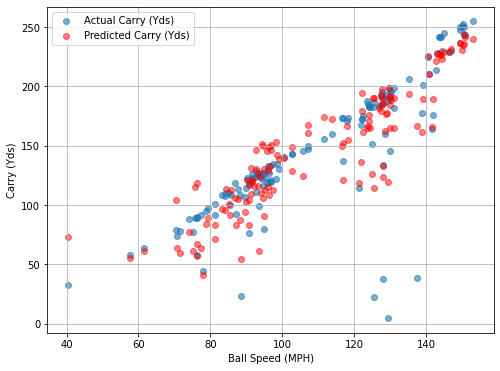

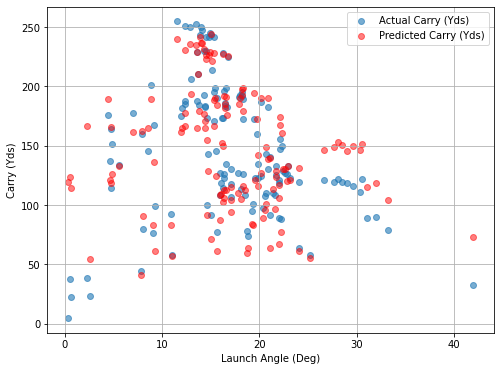

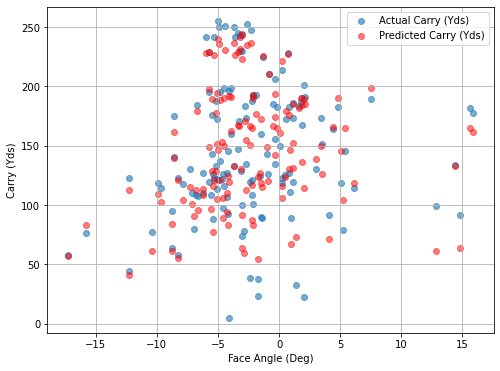

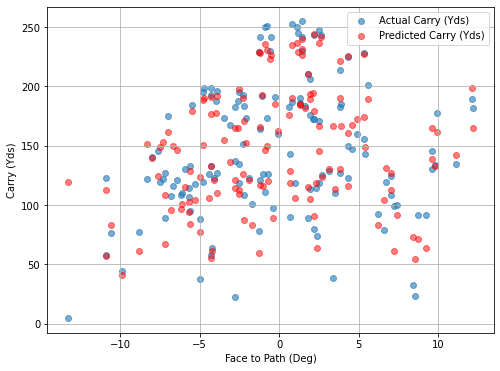

In [67]:
from sklearn.linear_model import LinearRegression
import numpy as np

#X are features and y is variable being predicted
X = df[['Ball Speed (MPH)', 'Launch Angle (Deg)', 'Face Angle (Deg)', 'Face to Path (Deg)']]
y = df['Carry (Yds)']

#standard regression procedure
reg = LinearRegression()
reg.fit(X, y)
y_pred = reg.predict(X)

coeff = model.coef_
intercept = model.intercept_

print("Coefficients:", coeff)
print("Intercept:", intercept)


plt.figure(figsize=(8, 6))
plt.scatter(X['Ball Speed (MPH)'], y, alpha=0.6, label='Actual Carry (Yds)')
plt.scatter(X['Ball Speed (MPH)'], y_pred, color='red', alpha=0.5, label='Predicted Carry (Yds)')
plt.xlabel("Ball Speed (MPH)")
plt.ylabel("Carry (Yds)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X['Launch Angle (Deg)'], y, alpha=0.6, label='Actual Carry (Yds)')
plt.scatter(X['Launch Angle (Deg)'], y_pred, color='red', alpha=0.5, label='Predicted Carry (Yds)')
plt.xlabel('Launch Angle (Deg)')
plt.ylabel("Carry (Yds)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X['Face Angle (Deg)'], y, alpha=0.6, label='Actual Carry (Yds)')
plt.scatter(X['Face Angle (Deg)'], y_pred, color='red', alpha=0.5, label='Predicted Carry (Yds)')
plt.xlabel('Face Angle (Deg)')
plt.ylabel("Carry (Yds)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X['Face to Path (Deg)'], y, alpha=0.6, label='Actual Carry (Yds)')
plt.scatter(X['Face to Path (Deg)'], y_pred, color='red', alpha=0.5, label='Predicted Carry (Yds)')
plt.xlabel('Face to Path (Deg)')
plt.ylabel("Carry (Yds)")
plt.legend()
plt.grid(True)
plt.show()

### R-Squared

R-squared: 0.8194778368730588


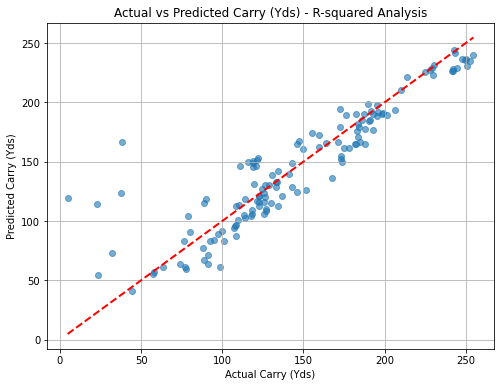

In [60]:
from sklearn.metrics import r2_score

y_pred = model.predict(X)
r_squared = r2_score(y, y_pred)
print("R-squared:", r_squared)

plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)  #line y=x for comparison
plt.xlabel("Actual Carry (Yds)")
plt.ylabel("Predicted Carry (Yds)")
plt.title("Actual vs Predicted Carry (Yds) - R-squared Analysis")
plt.grid(True)
plt.show()